In [1]:
# Week 1: Install libraries
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn -q

In [2]:
# Week 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, RepeatVector, TimeDistributed, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [3]:
# Week 1: Upload FD003 files
from google.colab import files
print("Please upload train_FD003.txt and test_FD003.txt")
uploaded = files.upload()

Please upload train_FD003.txt and test_FD003.txt


Saving train_FD003.txt to train_FD003.txt
Saving test_FD003.txt to test_FD003.txt


In [4]:
# Week 2: Load FD003 data
train = pd.read_csv('train_FD003.txt', sep=" ", header=None)
test = pd.read_csv('test_FD003.txt', sep=" ", header=None)

# Remove empty columns
train = train.dropna(axis=1, how='all')
test = test.dropna(axis=1, how='all')

In [5]:
# Week 2: Assign column names
cols = ['engine_id', 'cycle'] + [f'op_setting_{i}' for i in range(1,4)] + [f'sensor_{i}' for i in range(1,22)]
train.columns = cols
test.columns = cols

print("TRAIN DATASET INFO")
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
print(f"Number of engines in train: {train['engine_id'].nunique()}")
print(f"Number of engines in test: {test['engine_id'].nunique()}")
print(f"Total cycles in train: {train['cycle'].sum()}")
print(f"Total cycles in test: {test['cycle'].sum()}")
print("\nFirst 5 rows of training data:")
print(train.head())
print("\nMissing values in train:", train.isnull().sum().sum())
print("Missing values in test:", test.isnull().sum().sum())

TRAIN DATASET INFO
Train Shape: (24720, 26)
Test Shape: (16596, 26)
Number of engines in train: 100
Number of engines in test: 100
Total cycles in train: 3437985
Total cycles in test: 1759168

First 5 rows of training data:
   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0005        0.0004         100.0    518.67   
1          1      2        0.0008       -0.0003         100.0    518.67   
2          1      3       -0.0014       -0.0002         100.0    518.67   
3          1      4       -0.0020        0.0001         100.0    518.67   
4          1      5        0.0016        0.0000         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    642.36   1583.23   1396.84     14.62  ...     522.31    2388.01   
1    642.50   1584.69   1396.89     14.62  ...     522.42    2388.03   
2    642.18   1582.35   1405.61     14.62  ...     522.03    2388.00   
3    642.92   1585.61   1392.27     1

In [6]:
# Week 3: Remove low variance sensors (variance < 0.0001)
sensor_cols = [col for col in train.columns if 'sensor' in col]
print(f"\nTotal sensors initially: {len(sensor_cols)}")

variances = train[sensor_cols].var()
low_var_cols = variances[variances < 0.0001].index.tolist()
train = train.drop(columns=low_var_cols)
test = test.drop(columns=low_var_cols)
print(f"Removed {len(low_var_cols)} low variance sensors")

sensor_cols = [col for col in train.columns if 'sensor' in col]
print(f"Sensors after low variance removal: {len(sensor_cols)}")


Total sensors initially: 21
Removed 6 low variance sensors
Sensors after low variance removal: 15


In [7]:
# Week 3: Remove highly correlated sensors (>0.95)
corr_matrix = train[sensor_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]

train = train.drop(columns=high_corr_cols)
test = test.drop(columns=high_corr_cols)
print(f"Removed {len(high_corr_cols)} highly correlated sensors")

sensor_cols = [col for col in train.columns if 'sensor' in col]
print(f"Final sensors selected: {len(sensor_cols)}")
print(f"Sensors: {sensor_cols}")

Removed 3 highly correlated sensors
Final sensors selected: 12
Sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [8]:
# Week 4: Normalization (Z-score)
scaler = StandardScaler()
train[sensor_cols] = scaler.fit_transform(train[sensor_cols])
test[sensor_cols] = scaler.transform(test[sensor_cols])

print("\nNormalization complete!")
print(f"Train mean after normalization: {train[sensor_cols].mean().mean():.6f}")
print(f"Train std after normalization: {train[sensor_cols].std().mean():.6f}")


Normalization complete!
Train mean after normalization: -0.000000
Train std after normalization: 1.000020


In [9]:
# Week 4: Window segmentation
window_size = 30
anomaly_ratio = 0.20

def create_windows(data, window_size):
    X = []
    engine_ids = []
    for engine in data['engine_id'].unique():
        engine_data = data[data['engine_id'] == engine]
        for i in range(len(engine_data) - window_size):
            window = engine_data.iloc[i:i+window_size][sensor_cols].values
            X.append(window)
            engine_ids.append(engine)
    return np.array(X), engine_ids

def create_anomaly_labels(data, window_size, anomaly_ratio=0.20):
    labels = []
    for engine in data['engine_id'].unique():
        engine_data = data[data['engine_id'] == engine]
        max_cycle = engine_data['cycle'].max()
        anomaly_start_cycle = max_cycle - int(max_cycle * anomaly_ratio)
        for i in range(len(engine_data) - window_size):
            window_end_cycle = engine_data.iloc[i + window_size - 1]['cycle']
            if window_end_cycle >= anomaly_start_cycle:
                labels.append(1)
            else:
                labels.append(0)
    return np.array(labels)

In [10]:
# Week 4: Create windows and labels
print("\nCreating windows...")
X_train, train_engine_ids = create_windows(train, window_size)
X_test, test_engine_ids = create_windows(test, window_size)

y_train = create_anomaly_labels(train, window_size, anomaly_ratio)
y_test = create_anomaly_labels(test, window_size, anomaly_ratio)

print(f"\nWindows created successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nNormal samples in train: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"Anomaly samples in train: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")

# Extract only normal samples for training
X_train_normal = X_train[y_train == 0]
print(f"\nTraining on normal samples only: {X_train_normal.shape}")


Creating windows...

Windows created successfully!
X_train shape: (21720, 30, 12)
X_test shape: (13596, 30, 12)
y_train shape: (21720,)
y_test shape: (13596,)

Normal samples in train: 16814 (77.41%)
Anomaly samples in train: 4906 (22.59%)

Training on normal samples only: (16814, 30, 12)


Flattened input dimension: 360

Dense Autoencoder Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 360)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        46,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 360)            │        46,440 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,224 (426.66 KB)

 Trainable params: 109,224 (426.66 KB)

 Non-trainable params: 0 (0.00 B)


Training Dense Autoencoder...
Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.2931 - val_loss: 0.1555
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1698 - val_loss: 0.1508
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1632 - val_loss: 0.1463
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1570 - val_loss: 0.1410
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1505 - val_loss: 0.1370
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1442 - val_loss: 0.1325
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1399 - val_loss: 0.1296
Epoch 8/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1366 - val_loss: 0.1269
Epoch 9/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1339 - val_loss: 0.1248
Epoch 10/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1311 - val_loss: 0.1239
Epoch 11/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1293 - val_loss: 0.1226
Epoch 12/50
237/237

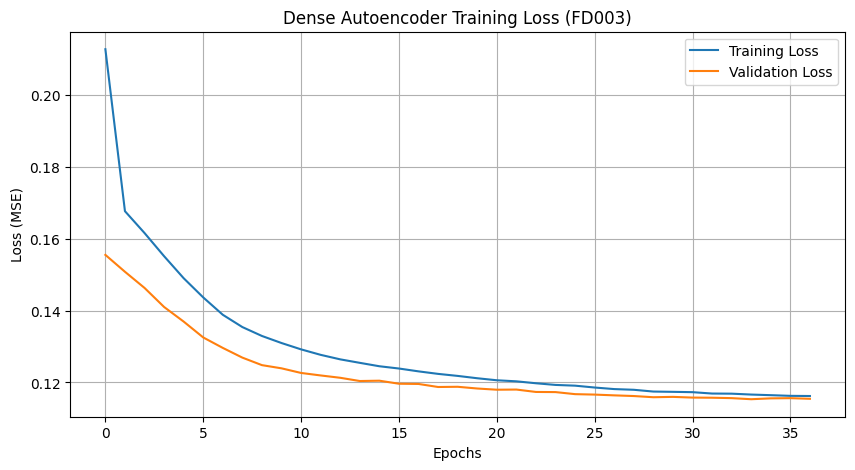

In [11]:
# Week 5: Dense Autoencoder
X_train_flat = X_train_normal.reshape(X_train_normal.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

input_dim = X_train_flat.shape[1]
print(f"Flattened input dimension: {input_dim}")

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

dense_ae = Model(input_layer, decoded)
dense_ae.compile(optimizer='adam', loss='mse')

print("\nDense Autoencoder Summary:")
dense_ae.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nTraining Dense Autoencoder...")
history_dense = dense_ae.fit(
    X_train_flat, X_train_flat,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_dense.history['loss'], label='Training Loss')
plt.plot(history_dense.history['val_loss'], label='Validation Loss')
plt.title('Dense Autoencoder Training Loss (FD003)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Timesteps: 30, Features: 12

LSTM Autoencoder Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 12)         │           780 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,516 (209.05 KB)

 Trainable params: 53,516 (209.05 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM Autoencoder...
Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.2511 - val_loss: 0.1572
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.1698 - val_loss: 0.1537
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1668 - val_loss: 0.1517
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1669 - val_loss: 0.1506
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1644 - val_loss: 0.1497
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1637 - val_loss: 0.1490
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1635 - val_loss: 0.1482
Epoch 8/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1630 - val_loss: 0.1475
Epoch 9/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1617 - val_loss: 0.1468
Epoch 10/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1612 - val_loss: 0.1463
Epoch 11/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1616 - val_loss: 0.1458
Epoch 12/50
237/

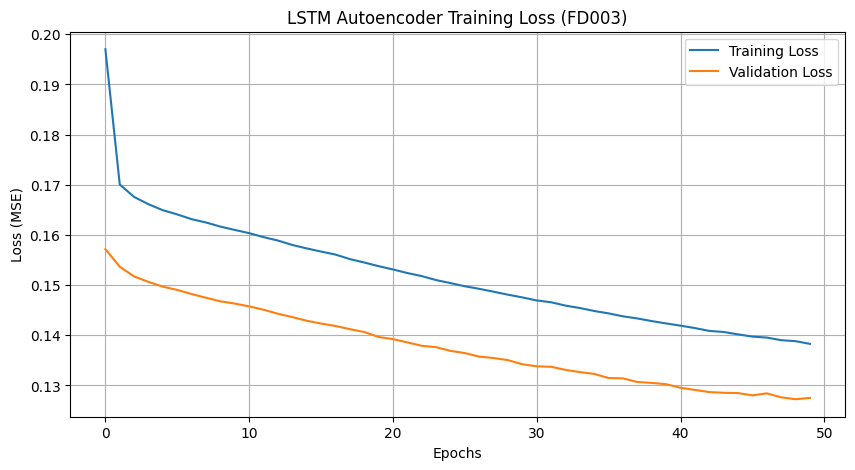

In [12]:
# Week 6: LSTM Autoencoder
timesteps = X_train.shape[1]
features = X_train.shape[2]
print(f"Timesteps: {timesteps}, Features: {features}")

input_layer = Input(shape=(timesteps, features))
encoded = LSTM(64, activation='tanh')(input_layer)
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, activation='tanh', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features))(decoded)

lstm_ae = Model(input_layer, decoded)
lstm_ae.compile(optimizer='adam', loss='mse')

print("\nLSTM Autoencoder Summary:")
lstm_ae.summary()

print("\nTraining LSTM Autoencoder...")
history_lstm = lstm_ae.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Autoencoder Training Loss (FD003)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


CNN-LSTM Autoencoder Summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        16,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 12)         │           612 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,596 (150.77 KB)

 Trainable params: 38,596 (150.77 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN-LSTM Autoencoder...
Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.2545 - val_loss: 0.1569
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1711 - val_loss: 0.1546
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1690 - val_loss: 0.1528
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1676 - val_loss: 0.1524
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1670 - val_loss: 0.1513
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1660 - val_loss: 0.1508
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1652 - val_loss: 0.1506
Epoch 8/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1654 - val_loss: 0.1497
Epoch 9/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1638 - val_loss: 0.1494
Epoch 10/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1630 - val_loss: 0.1490
Epoch 11/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1633 - val_loss: 0.1486
Epoch 1

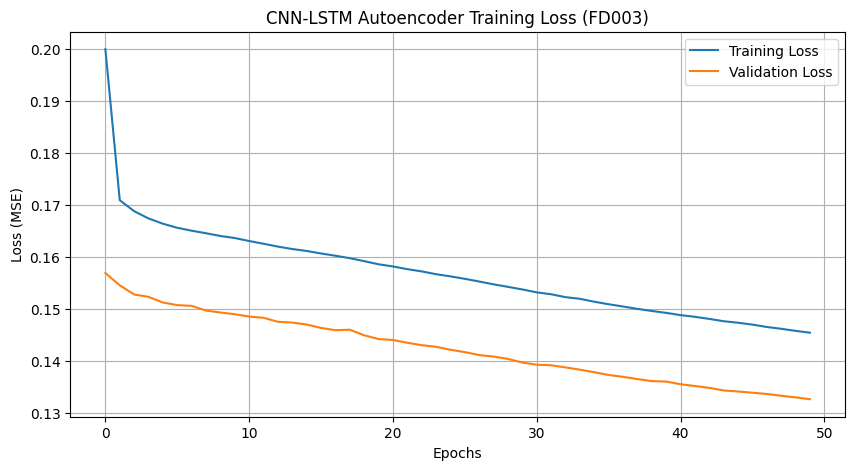

In [13]:
# Week 7: CNN-LSTM Autoencoder
input_layer = Input(shape=(timesteps, features))
x = Conv1D(32, 3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(pool_size=2)(x)
x = LSTM(50, return_sequences=False)(x)
x = RepeatVector(timesteps)(x)
x = LSTM(50, return_sequences=True)(x)
decoded = TimeDistributed(Dense(features))(x)

cnn_lstm = Model(input_layer, decoded)
cnn_lstm.compile(optimizer='adam', loss='mse')

print("\nCNN-LSTM Autoencoder Summary:")
cnn_lstm.summary()

print("\nTraining CNN-LSTM Autoencoder...")
history_cnn = cnn_lstm.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(10, 5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN-LSTM Autoencoder Training Loss (FD003)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Week 8: Threshold selection
def compute_reconstruction_error(model, X, flatten=False):
    if flatten:
        X_pred = model.predict(X, verbose=0)
        mse = np.mean((X - X_pred) ** 2, axis=1)
    else:
        X_pred = model.predict(X, verbose=0)
        mse = np.mean((X - X_pred) ** 2, axis=(1, 2))
    return mse

# Validation split
val_size = int(len(X_train_normal) * 0.1)
X_val = X_train_normal[:val_size]
X_train_norm = X_train_normal[val_size:]

# Dense AE
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_train_norm_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)

errors_dense_val = compute_reconstruction_error(dense_ae, X_val_flat, flatten=True)
errors_lstm_val = compute_reconstruction_error(lstm_ae, X_val)
errors_cnn_val = compute_reconstruction_error(cnn_lstm, X_val)

errors_train_dense = compute_reconstruction_error(dense_ae, X_train_norm_flat, flatten=True)
errors_train_lstm = compute_reconstruction_error(lstm_ae, X_train_norm)
errors_train_cnn = compute_reconstruction_error(cnn_lstm, X_train_norm)

thresh_dense_p95 = np.percentile(errors_train_dense, 95)
thresh_lstm_p95 = np.percentile(errors_train_lstm, 95)
thresh_cnn_p95 = np.percentile(errors_train_cnn, 95)

def find_threshold_by_fpr(errors_val, target_fpr=0.05):
    sorted_errors = np.sort(errors_val)
    index = int(len(sorted_errors) * (1 - target_fpr))
    index = min(index, len(sorted_errors) - 1)
    return sorted_errors[index]

thresh_dense_val = find_threshold_by_fpr(errors_dense_val, target_fpr=0.05)
thresh_lstm_val = find_threshold_by_fpr(errors_lstm_val, target_fpr=0.05)
thresh_cnn_val = find_threshold_by_fpr(errors_cnn_val, target_fpr=0.05)

print("\nThreshold values (FD003):")
print(f"Dense AE  - P95: {thresh_dense_p95:.4f}, Validation (FPR≤5%): {thresh_dense_val:.4f}")
print(f"LSTM AE   - P95: {thresh_lstm_p95:.4f}, Validation (FPR≤5%): {thresh_lstm_val:.4f}")
print(f"CNN-LSTM  - P95: {thresh_cnn_p95:.4f}, Validation (FPR≤5%): {thresh_cnn_val:.4f}")


Threshold values (FD003):
Dense AE  - P95: 0.1626, Validation (FPR≤5%): 0.1311
LSTM AE   - P95: 0.2428, Validation (FPR≤5%): 0.1457
CNN-LSTM  - P95: 0.2647, Validation (FPR≤5%): 0.1527


In [15]:
# Week 9: Model evaluation
errors_test_dense = compute_reconstruction_error(dense_ae, X_test_flat, flatten=True)
errors_test_lstm = compute_reconstruction_error(lstm_ae, X_test)
errors_test_cnn = compute_reconstruction_error(cnn_lstm, X_test)

# Inference time
start_time = time.time()
_ = dense_ae.predict(X_test_flat[:100], verbose=0)
inf_time_dense = (time.time() - start_time) / 100
start_time = time.time()
_ = lstm_ae.predict(X_test[:100], verbose=0)
inf_time_lstm = (time.time() - start_time) / 100
start_time = time.time()
_ = cnn_lstm.predict(X_test[:100], verbose=0)
inf_time_cnn = (time.time() - start_time) / 100

def evaluate_model(y_true, errors, threshold, model_name, threshold_type, inference_time):
    y_pred = (errors > threshold).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, errors)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    return {
        'Model': model_name,
        'Threshold Type': threshold_type,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4),
        'False Alarm Rate': round(far, 4),
        'Inference Time (s)': round(inference_time, 6)
    }

results = []
results.append(evaluate_model(y_test, errors_test_dense, thresh_dense_p95, 'Dense AE', 'Percentile (95th)', inf_time_dense))
results.append(evaluate_model(y_test, errors_test_lstm, thresh_lstm_p95, 'LSTM AE', 'Percentile (95th)', inf_time_lstm))
results.append(evaluate_model(y_test, errors_test_cnn, thresh_cnn_p95, 'CNN-LSTM', 'Percentile (95th)', inf_time_cnn))
results.append(evaluate_model(y_test, errors_test_dense, thresh_dense_val, 'Dense AE', 'Validation (FPR≤5%)', inf_time_dense))
results.append(evaluate_model(y_test, errors_test_lstm, thresh_lstm_val, 'LSTM AE', 'Validation (FPR≤5%)', inf_time_lstm))
results.append(evaluate_model(y_test, errors_test_cnn, thresh_cnn_val, 'CNN-LSTM', 'Validation (FPR≤5%)', inf_time_cnn))

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("FINAL RESULTS - FD003 ANOMALY DETECTION PERFORMANCE")
print("="*80)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv('anomaly_detection_results_FD003.csv', index=False)
print("\nResults saved to 'anomaly_detection_results_FD003.csv'")


FINAL RESULTS - FD003 ANOMALY DETECTION PERFORMANCE
   Model      Threshold Type  Precision  Recall  F1-Score  ROC-AUC  False Alarm Rate  Inference Time (s)
Dense AE   Percentile (95th)     0.1414  0.0479    0.0716   0.4771            0.0924            0.006720
 LSTM AE   Percentile (95th)     0.0934  0.0235    0.0376   0.4476            0.0724            0.001267
CNN-LSTM   Percentile (95th)     0.0903  0.0220    0.0353   0.4554            0.0703            0.002076
Dense AE Validation (FPR≤5%)     0.2217  0.1633    0.1880   0.4771            0.1820            0.006720
 LSTM AE Validation (FPR≤5%)     0.1617  0.1016    0.1248   0.4476            0.1673            0.001267
CNN-LSTM Validation (FPR≤5%)     0.1792  0.1086    0.1353   0.4554            0.1581            0.002076

Results saved to 'anomaly_detection_results_FD003.csv'


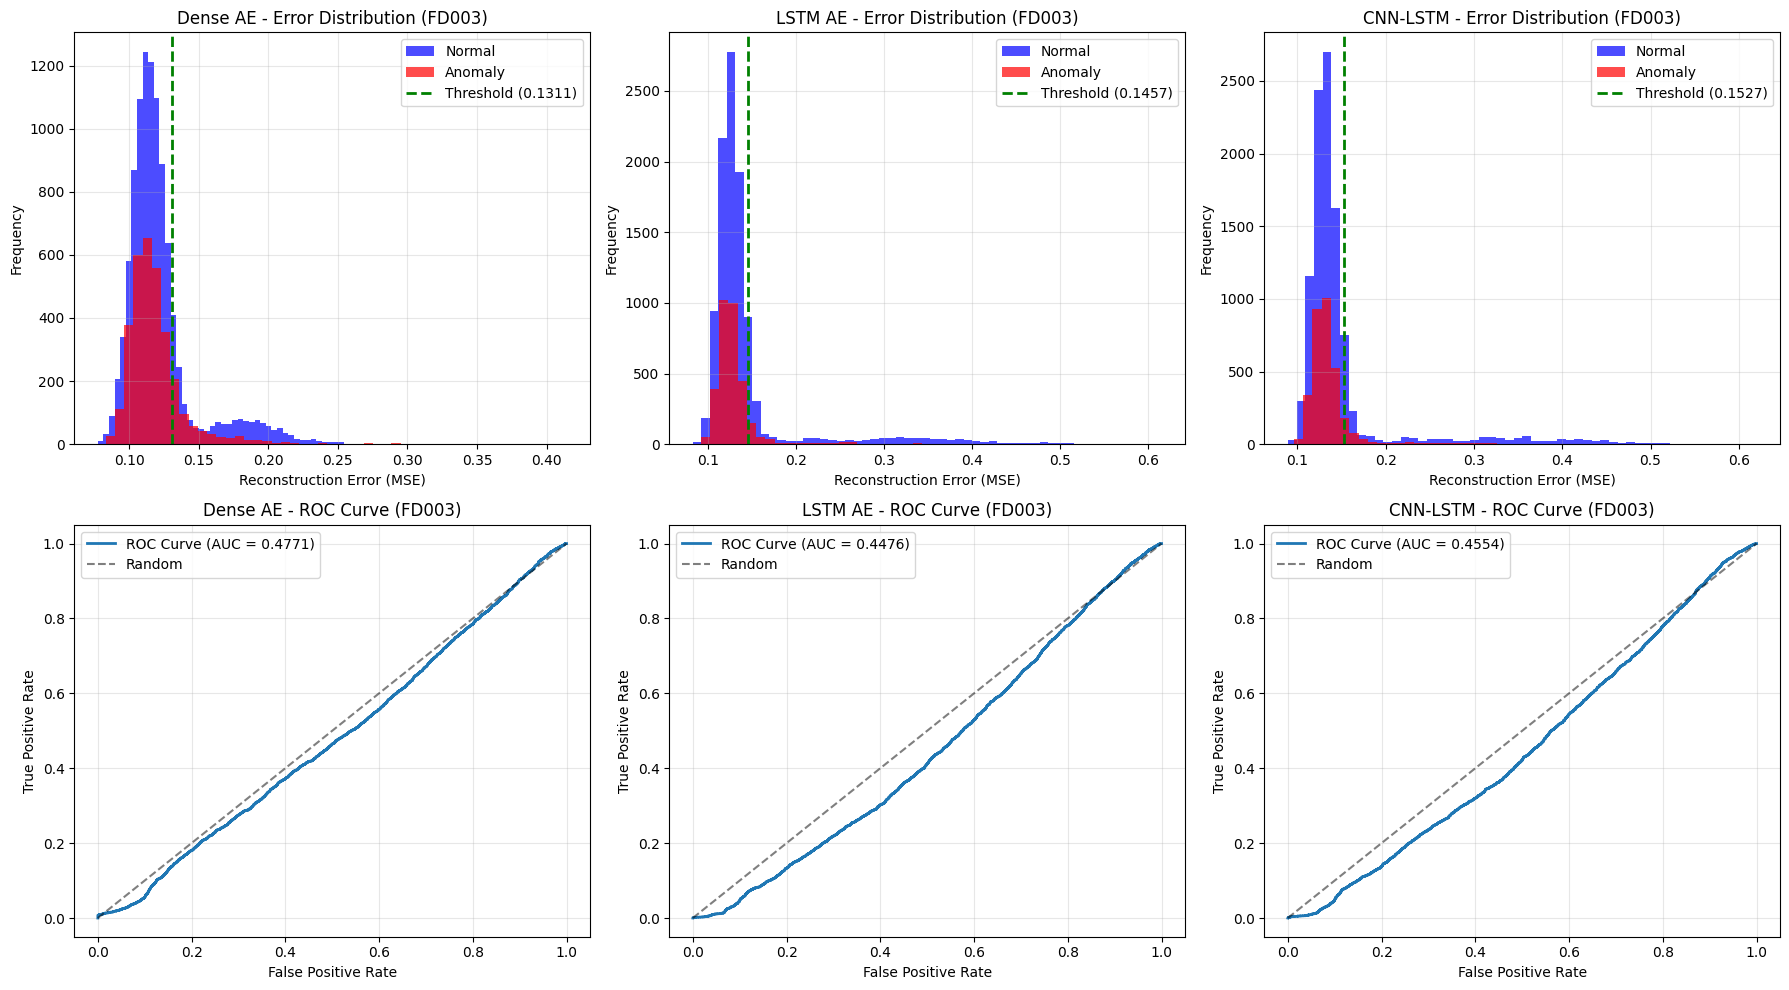

Figure saved: fd003_error_roc.png


In [16]:
# Week 9: Visualizations
models = ['Dense AE', 'LSTM AE', 'CNN-LSTM']
errors_list = [errors_test_dense, errors_test_lstm, errors_test_cnn]
thresholds_val = [thresh_dense_val, thresh_lstm_val, thresh_cnn_val]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 0: Error distributions
for i, (ax, name, errors, thresh) in enumerate(zip(axes[0], models, errors_list, thresholds_val)):
    ax.hist(errors[y_test==0], bins=50, alpha=0.7, label='Normal', color='blue')
    ax.hist(errors[y_test==1], bins=50, alpha=0.7, label='Anomaly', color='red')
    ax.axvline(thresh, color='green', linestyle='--', linewidth=2, label=f'Threshold ({thresh:.4f})')
    ax.set_title(f'{name} - Error Distribution (FD003)')
    ax.set_xlabel('Reconstruction Error (MSE)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Row 1: ROC Curves
for i, (ax, name, errors) in enumerate(zip(axes[1], models, errors_list)):
    fpr, tpr, _ = roc_curve(y_test, errors)
    auc = roc_auc_score(y_test, errors)
    ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    ax.set_title(f'{name} - ROC Curve (FD003)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fd003_error_roc.png', dpi=300)
plt.show()
print("Figure saved: fd003_error_roc.png")

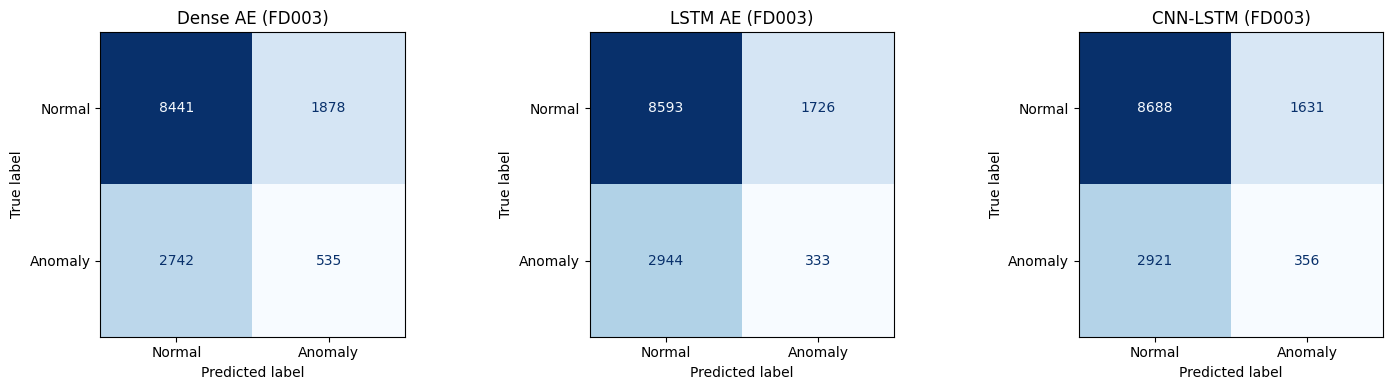

Figure saved: fd003_confusion_matrices.png


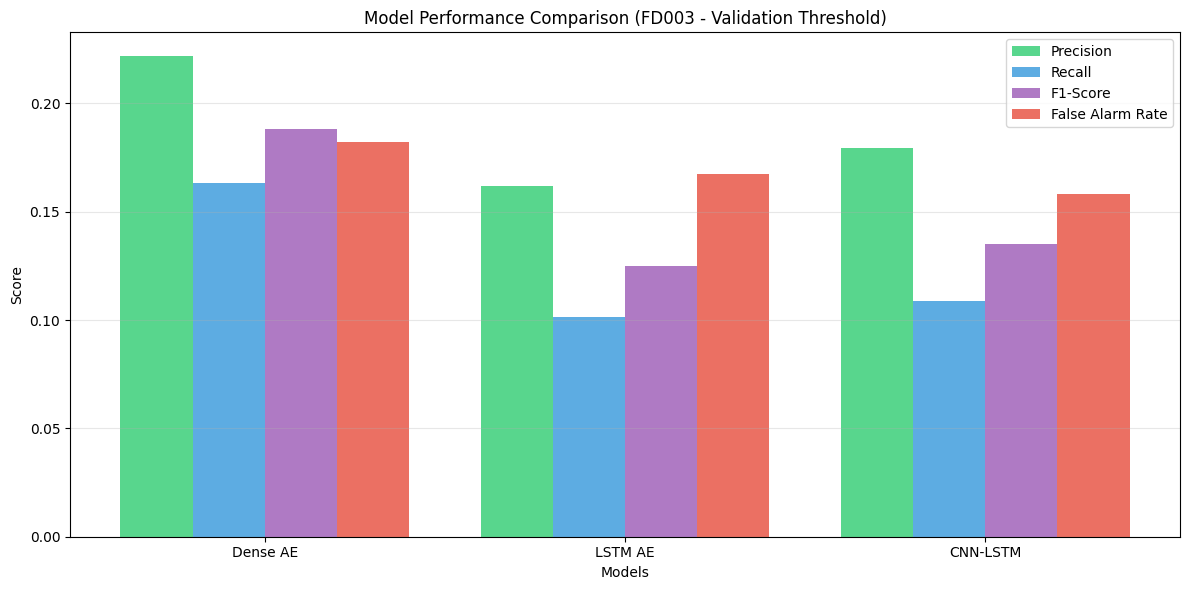

Figure saved: fd003_bar_chart.png


In [17]:
# Week 9: Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name, errors, thresh in zip(axes, models, errors_list, thresholds_val):
    y_pred = (errors > thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} (FD003)')
plt.tight_layout()
plt.savefig('fd003_confusion_matrices.png', dpi=300)
plt.show()
print("Figure saved: fd003_confusion_matrices.png")

# Bar chart
val_results = results_df[results_df['Threshold Type'] == 'Validation (FPR≤5%)']
x = np.arange(len(val_results))
width = 0.2
metrics = ['Precision', 'Recall', 'F1-Score', 'False Alarm Rate']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = val_results[metric].values
    ax.bar(x + i*width, values, width, label=metric, color=color, alpha=0.8)
ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (FD003 - Validation Threshold)')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(val_results['Model'].values)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fd003_bar_chart.png', dpi=300)
plt.show()
print("Figure saved: fd003_bar_chart.png")

In [18]:
# Week 10: Output collection for Chapter 4 (FD003)
print("="*60)
print("📌 FD003 DATASET STATISTICS")
print("="*60)
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Engines in train: {train['engine_id'].nunique()}")
print(f"Engines in test: {test['engine_id'].nunique()}")
print(f"Final sensors selected: {len(sensor_cols)}")

print("\n" + "="*60)
print("📌 CLASS DISTRIBUTION")
print("="*60)
print(f"TRAIN: Normal: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.2f}%), "
      f"Anomaly: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")
print(f"TEST:  Normal: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.2f}%), "
      f"Anomaly: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")

print("\n" + "="*60)
print("📌 THRESHOLD VALUES")
print("="*60)
print(f"Dense AE  - P95: {thresh_dense_p95:.6f}, Val: {thresh_dense_val:.6f}")
print(f"LSTM AE   - P95: {thresh_lstm_p95:.6f}, Val: {thresh_lstm_val:.6f}")
print(f"CNN-LSTM  - P95: {thresh_cnn_p95:.6f}, Val: {thresh_cnn_val:.6f}")

print("\n" + "="*60)
print("📌 FINAL RESULTS TABLE (FD003)")
print("="*60)
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("✅ FD003 implementation complete! All results saved.")
print("="*60)

📌 FD003 DATASET STATISTICS
Train shape: (24720, 17)
Test shape: (16596, 17)
Engines in train: 100
Engines in test: 100
Final sensors selected: 12

📌 CLASS DISTRIBUTION
TRAIN: Normal: 16814 (77.41%), Anomaly: 4906 (22.59%)
TEST:  Normal: 10319 (75.90%), Anomaly: 3277 (24.10%)

📌 THRESHOLD VALUES
Dense AE  - P95: 0.162594, Val: 0.131099
LSTM AE   - P95: 0.242808, Val: 0.145702
CNN-LSTM  - P95: 0.264690, Val: 0.152712

📌 FINAL RESULTS TABLE (FD003)
   Model      Threshold Type  Precision  Recall  F1-Score  ROC-AUC  False Alarm Rate  Inference Time (s)
Dense AE   Percentile (95th)     0.1414  0.0479    0.0716   0.4771            0.0924            0.006720
 LSTM AE   Percentile (95th)     0.0934  0.0235    0.0376   0.4476            0.0724            0.001267
CNN-LSTM   Percentile (95th)     0.0903  0.0220    0.0353   0.4554            0.0703            0.002076
Dense AE Validation (FPR≤5%)     0.2217  0.1633    0.1880   0.4771            0.1820            0.006720
 LSTM AE Validation (FPR≤